In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer,
)

from sentence_transformers import SentenceTransformer

import wandb

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

In [3]:
# ============================================
# Reproducibility
# ============================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#### for the wandb login `wandb.login()` 
# Data Loading and Data information

The Smart MCQ Solver Challenge dataset consists of multiple-choice questions, where each question contains a prompt and five possible answer options (A–E). The training dataset also includes the correct answer label, while the test dataset contains only the questions and answer choices.

In this section, we load the datasets and create working copies that will be used throughout the notebook. The original datasets remain unchanged to preserve the raw data.

In [4]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

test_cc = test.copy()
train_cc = train.copy()
sample_submission_cc = sample_submission.copy()

print("=" * 60)
print("Training Dataset")
print("=" * 60)
print(f"Shape : {train_cc.shape}")
print("=" * 60)
print("Testing Dataset")
print("=" * 60)
print(f"Shape : {test_cc.shape}")
print("=" * 60)
print("Sample Submission")
print("=" * 60)
print(f"Shape : {sample_submission_cc.shape}")

Training Dataset
Shape : (2000, 8)
Testing Dataset
Shape : (500, 7)
Sample Submission
Shape : (500, 2)


In [5]:
print("=" * 60)
print("Training Dataset")
print("=" * 60)
display(train_cc.head())
print("=" * 60)
print("Test Dataset")
print("=" * 60)
display(test_cc.head())

Training Dataset


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


Test Dataset


,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [6]:
print("=" * 60)
print("Training Dataset information")
print("=" * 60)
display(train_cc.info())
print("=" * 60)
print("Test Dataset")
print("=" * 60)
display(test_cc.info())

Training Dataset information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


None

Test Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


None

# EDA (Exploratory Data Analysis)
## Missing Value Analysis

In [7]:
print("Training Dataset Missing Values")
display(train_cc.isnull().sum())

Training Dataset Missing Values


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

No missing values were found in either the training or testing dataset. Therefore, no imputation or missing value handling is required.

## Duplicate Analysis

In [8]:
train_duplicates = train_cc.drop(columns=["id"]).duplicated().sum()
print(f"Duplicate rows in Training Dataset : {train_duplicates}")

Duplicate rows in Training Dataset : 183


Observation

- After excluding the unique `id` column, the training dataset contains **183 duplicate records**.
- These duplicates indicate that some multiple-choice questions appear more than once in the dataset.
- Since repeated questions may provide additional learning signals and are part of the original competition dataset, they are retained rather than removed.
- Removing these duplicates could alter the original training distribution and may affect model performance on the competition benchmark.

## Target Class Distribution

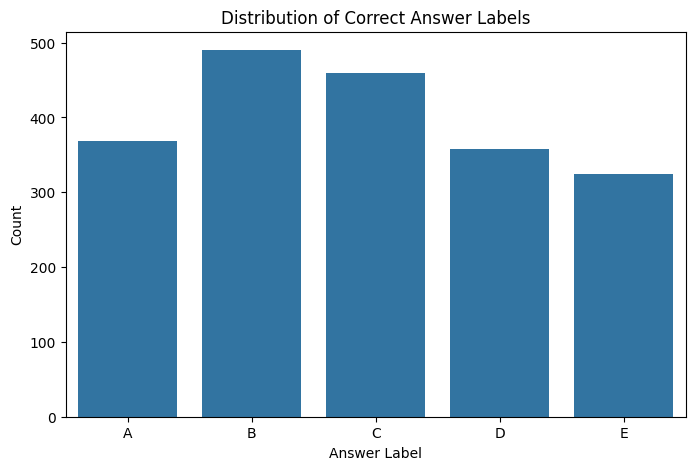

In [9]:
# =====================================================
# Target Distribution
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=train_cc,
    x="answer",
    order=sorted(train_cc["answer"].unique())
)

plt.title("Distribution of Correct Answer Labels")
plt.xlabel("Answer Label")
plt.ylabel("Count")

plt.show()

Observation

- The target labels are reasonably well distributed across the five answer classes.
- Labels **B** and **C** occur more frequently than the remaining classes, while **E** has the fewest samples.
- Although the dataset is not perfectly balanced, the class imbalance is relatively small and is unlikely to require additional balancing techniques such as oversampling or class weighting.
- Overall, the distribution suggests that the model will receive sufficient examples from every class during training.

## Prompt Length Distribution

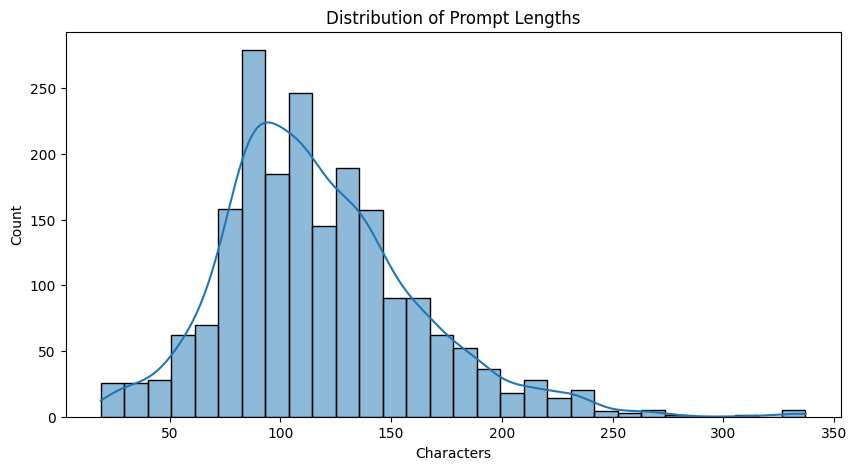

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64


In [10]:
train_cc["prompt_length"] = train_cc["prompt"].str.len()
plt.figure(figsize=(10,5))

sns.histplot(
    train_cc["prompt_length"],
    bins=30,
    kde=True
)

plt.title("Distribution of Prompt Lengths")

plt.xlabel("Characters")

plt.show()
print(train_cc["prompt_length"].describe())

Observation

- The average prompt length is approximately **118 characters**, with a median length of **111 characters**.
- Most questions fall within the range of **80–150 characters**, indicating that the majority of prompts are relatively concise.
- A small number of longer questions extend beyond **250 characters**, producing a slight right-skew in the distribution.
- Since prompt lengths remain within a manageable range, sequence truncation is unlikely to remove substantial information when an appropriate maximum sequence length is chosen.

## Option Length Analysis

In [11]:
for col in ["A","B","C","D","E"]:
    train_cc[f"{col}_length"] = train_cc[col].str.len()
option_lengths = train_cc[
    ["A_length","B_length","C_length","D_length","E_length"]
]

option_lengths.describe().T

,count,mean,std,min,25%,50%,75%,max
A_length,2000.0,164.0915,105.677145,1.0,86.0,143.0,234.0,472.0
B_length,2000.0,166.6165,113.829917,2.0,82.0,151.0,222.0,662.0
C_length,2000.0,167.2270,105.723674,2.0,88.0,158.0,224.0,530.0
D_length,2000.0,162.5635,104.116570,1.0,91.0,141.0,231.0,450.0
E_length,2000.0,164.2300,107.777712,2.0,84.0,144.0,224.0,587.0


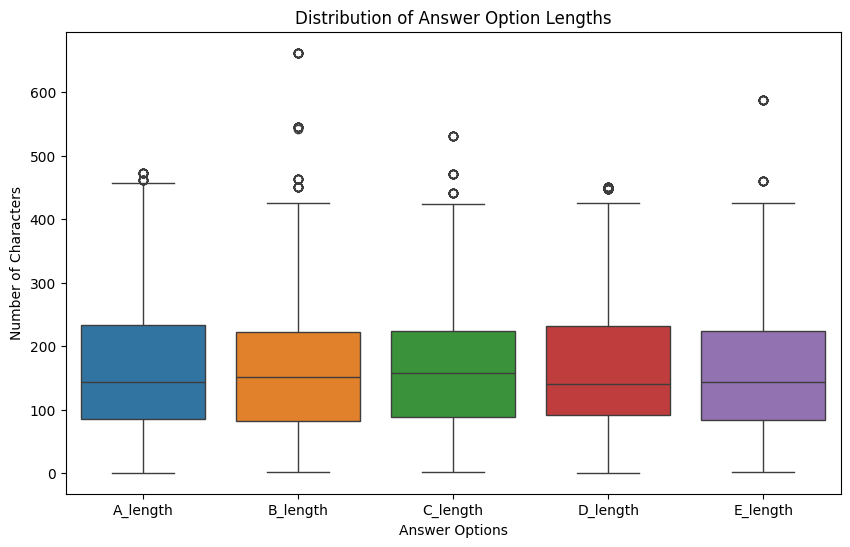

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=option_lengths)

plt.title("Distribution of Answer Option Lengths")
plt.xlabel("Answer Options")
plt.ylabel("Number of Characters")

plt.show()

Observation

- The average lengths of answer options are highly consistent across all five choices, ranging from approximately **162 to 167 characters**.
- This indicates that the dataset was carefully constructed, with answer options having comparable textual lengths.
- Since no option is consistently longer or shorter than the others, the model is less likely to learn superficial biases based solely on answer length.
- Consequently, the model will need to rely on the semantic relationship between the question and its answer choices rather than simple statistical cues.

## Random MCQ examples

In [13]:
sample = train_cc.sample(3, random_state=42)
display(sample)

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length
1860,1861,Select the most accurate option: What is the p...,The propagation constant is a measure of the a...,The propagation constant is a real number that...,The propagation constant is a real number that...,The propagation constant is a complex number t...,The propagation constant is a complex number t...,D,97,104,125,115,118,128
353,354,Pick the best possible answer: What is the mos...,The pressure differential between the inside a...,The reduce in velocity resulting in an boost i...,The movement of air across the outside surface...,The use of cold water,Bernoulli's principle,E,124,70,56,68,21,21
1333,1334,Pick the best possible answer: What is the Kel...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,The Kelvin-Helmholtz instability is a phenomen...,A,145,362,155,180,195,310


- Randomly sampled questions demonstrate that the dataset covers diverse topics, including science, philosophy, physics, astronomy, history, and general knowledge.
- The answer options are often semantically similar, requiring contextual understanding rather than simple keyword matching.
- This diversity highlights the need for models capable of capturing deeper semantic relationships between the question prompt and each candidate answer.

# Data Preprocessing
Data Preprocessing

│

├── 1. Label Encoding

├── 2. Text Data Validation

├── 3. Text Cleaning

└── 4. MCQ Formatting (Question-Option Pairs)



## Label Encoding
# Label Encoding

The target variable (`answer`) consists of categorical labels representing the correct answer option (`A`, `B`, `C`, `D`, and `E`). Since machine learning and deep learning models require numerical targets during training, these labels are converted into integer values using `LabelEncoder`.

The original `answer` column is preserved to maintain interpretability, while a new column named `label` is created for model training.

In [14]:
# =====================================================
# Label Encoding
# =====================================================

label_encoder = LabelEncoder()

train_cc["label"] = label_encoder.fit_transform(train_cc["answer"])

mapping = pd.DataFrame({
    "Answer Label": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

display(mapping)

train_cc[["answer", "label"]].head()

,Answer Label,Encoded Label
0,A,0
1,B,1
2,C,2
3,D,3
4,E,4


,answer,label
0,B,1
1,A,0
2,C,2
3,B,1
4,A,0


Observation

The categorical target labels have been successfully converted into numerical values while preserving the original answer column. This numerical representation will be used during model training, whereas the original labels will later be recovered for generating the final competition submission.

## Text Data Validation
Before performing text preprocessing, all textual columns are explicitly converted to the `string` data type. Although the dataset already stores these columns as objects, converting them to strings ensures consistency and prevents unexpected errors during text cleaning, tokenization, and feature extraction.

This step guarantees that every question prompt and answer option can be processed uniformly by both classical machine learning and deep learning models.

In [15]:
# =====================================================
# Text Data Validation
# =====================================================

text_columns = ["prompt", "A", "B", "C", "D", "E"]

train_cc[text_columns] = train_cc[text_columns].astype(str)
display(train_cc[text_columns].dtypes)
print("=" * 60)
print("Additional validation")
print("=" * 60)
for column in text_columns:
    print(f"{column}: {type(train_cc[column].iloc[0]).__name__}")

prompt    object
A         object
B         object
C         object
D         object
E         object
dtype: object

Additional validation
prompt: str
A: str
B: str
C: str
D: str
E: str


Observation

>All textual columns were successfully converted to string format. This ensures a consistent data representation across the dataset and avoids type-related issues during subsequent preprocessing steps such as text cleaning, vectorization, and tokenization.

## Text Cleaning

To preserve the semantic and grammatical structure of the questions, only minimal text preprocessing is performed.

Unlike traditional NLP pipelines, aggressive preprocessing techniques such as lowercasing, punctuation removal, stop-word removal, stemming, and lemmatization are intentionally avoided. This is because pretrained transformer models benefit from retaining the original sentence structure and punctuation.

The cleaning process is therefore limited to:

- Removing leading and trailing whitespace.
- Replacing multiple consecutive spaces with a single space.
- Removing unnecessary newline and tab characters.

This lightweight preprocessing ensures consistency while preserving the contextual information required by both classical machine learning and transformer-based models.

In [16]:
import re

def clean_text(text):

    text = text.replace("\n", " ")
    text = text.replace("\t", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

sample_text = "  This   is   a\t sample\ntext.   "

print("Before Cleaning:")
print(repr(sample_text))

print("\nAfter Cleaning:")
print(repr(clean_text(sample_text)))

Before Cleaning:
'  This   is   a\t sample\ntext.   '

After Cleaning:
'This is a sample text.'


This is the function for the Text cleaning which we will use later inside each models pipeline.

## MCQ Formatting
For every multiple-choice question, five Question–Option pairs are created:

- Prompt + Option A
- Prompt + Option B
- Prompt + Option C
- Prompt + Option D
- Prompt + Option E

This representation allows every candidate answer to be evaluated independently and can be reused across all three models developed in this project.

In [17]:
def create_question_option_pair(question, option):
    return (
        f"Question: {question}\n"
        f"Answer: {option}"
    )

print("=" * 60)
print("Test for the create_question_option_pair function")
print("=" * 60)

sample_row = train_cc.iloc[0]

print(
    create_question_option_pair(
        sample_row["prompt"],
        sample_row["A"]
    )
)

Test for the create_question_option_pair function
Question: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Answer: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
